# Wheather Forecasting with Machine Learning

<img src='https://www.shutterstock.com/image-vector/tv-show-host-tells-about-260nw-2033509361.jpg'>

🇹🇷 Türkçe

Bu çalışmada, Prophet kütüphanesi kullanılarak hava durumu verileri üzerinde zaman serisi analizi gerçekleştirilmiş ve 7 günlük (kısa vadeli) ile 30 günlük (orta vadeli) tahminler üretilmiştir.

🇬🇧 English 

In this study, time series analysis was conducted on weather data using the Prophet library, and 7-day (short-term) and 30-day (medium-term) forecasts were generated.

In [16]:
#!pip install prophet

In [43]:
import pandas as pd
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [4]:
train_df=pd.read_csv('DailyDelhiClimateTrain.csv')
test_df=pd.read_csv('DailyDelhiClimateTest.csv')

In [5]:
train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [7]:
test_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [12]:
df = pd.concat([train_df, test_df], ignore_index=True)

In [13]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1576 non-null   object 
 1   meantemp      1576 non-null   float64
 2   humidity      1576 non-null   float64
 3   wind_speed    1576 non-null   float64
 4   meanpressure  1576 non-null   float64
dtypes: float64(4), object(1)
memory usage: 61.7+ KB


In [35]:
df.describe()

,date,meantemp,humidity,wind_speed,meanpressure
count,1576,1576.000000,1576.000000,1576.000000,1576.000000
mean,2015-02-27 10:15:50.253807104,25.221918,60.445229,6.899262,1010.593178
min,2013-01-01 00:00:00,6.000000,13.428571,0.000000,-3.041667
25%,2014-01-29 18:00:00,18.500000,49.750000,3.700000,1001.875000
50%,2015-02-27 12:00:00,27.166667,62.440476,6.363571,1009.055556
75%,2016-03-27 06:00:00,31.142857,72.125000,9.262500,1015.200000
max,2017-04-24 00:00:00,38.714286,100.000000,42.220000,7679.333333
std,NaN,7.345014,16.979994,4.510725,175.242704


In [37]:
# Data Visualition

In [27]:
df['date'] = pd.to_datetime(df['date'])

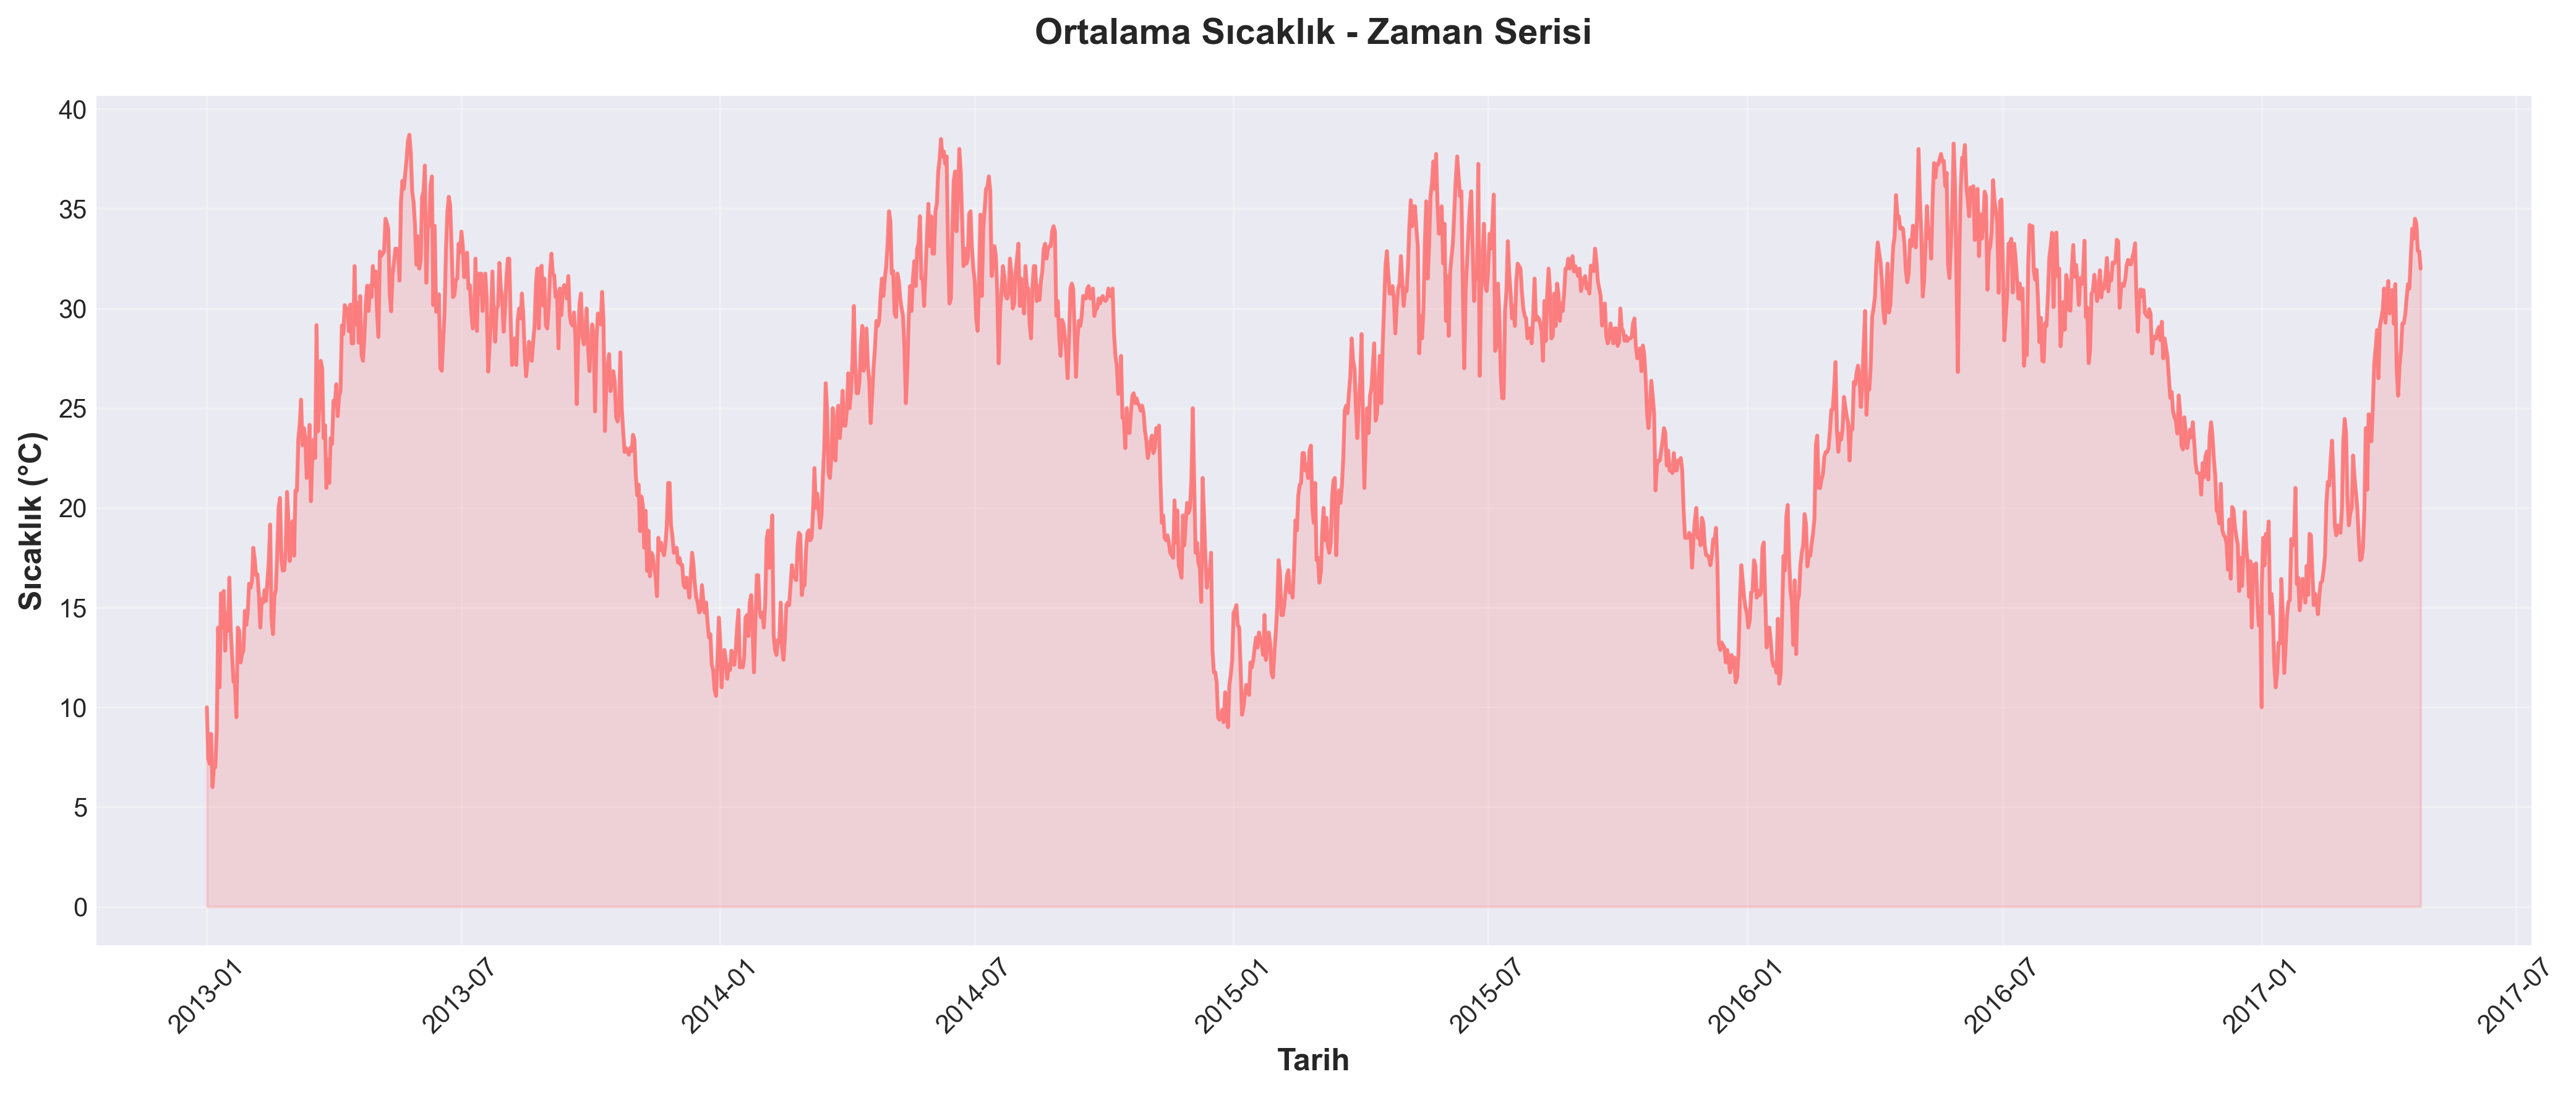

In [28]:
plt.style.use('seaborn-v0_8-darkgrid')

# SICAKLIK ZAMANSERİSİ
plt.figure(figsize=(14, 6), dpi=300)
plt.plot(df['date'], df['meantemp'], color='#FF6B6B', linewidth=1.5, alpha=0.8)
plt.fill_between(df['date'], df['meantemp'], alpha=0.2, color='#FF6B6B')
plt.xlabel('Tarih', fontsize=12, fontweight='bold')
plt.ylabel('Sıcaklık (°C)', fontsize=12, fontweight='bold')
plt.title('Ortalama Sıcaklık - Zaman Serisi', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

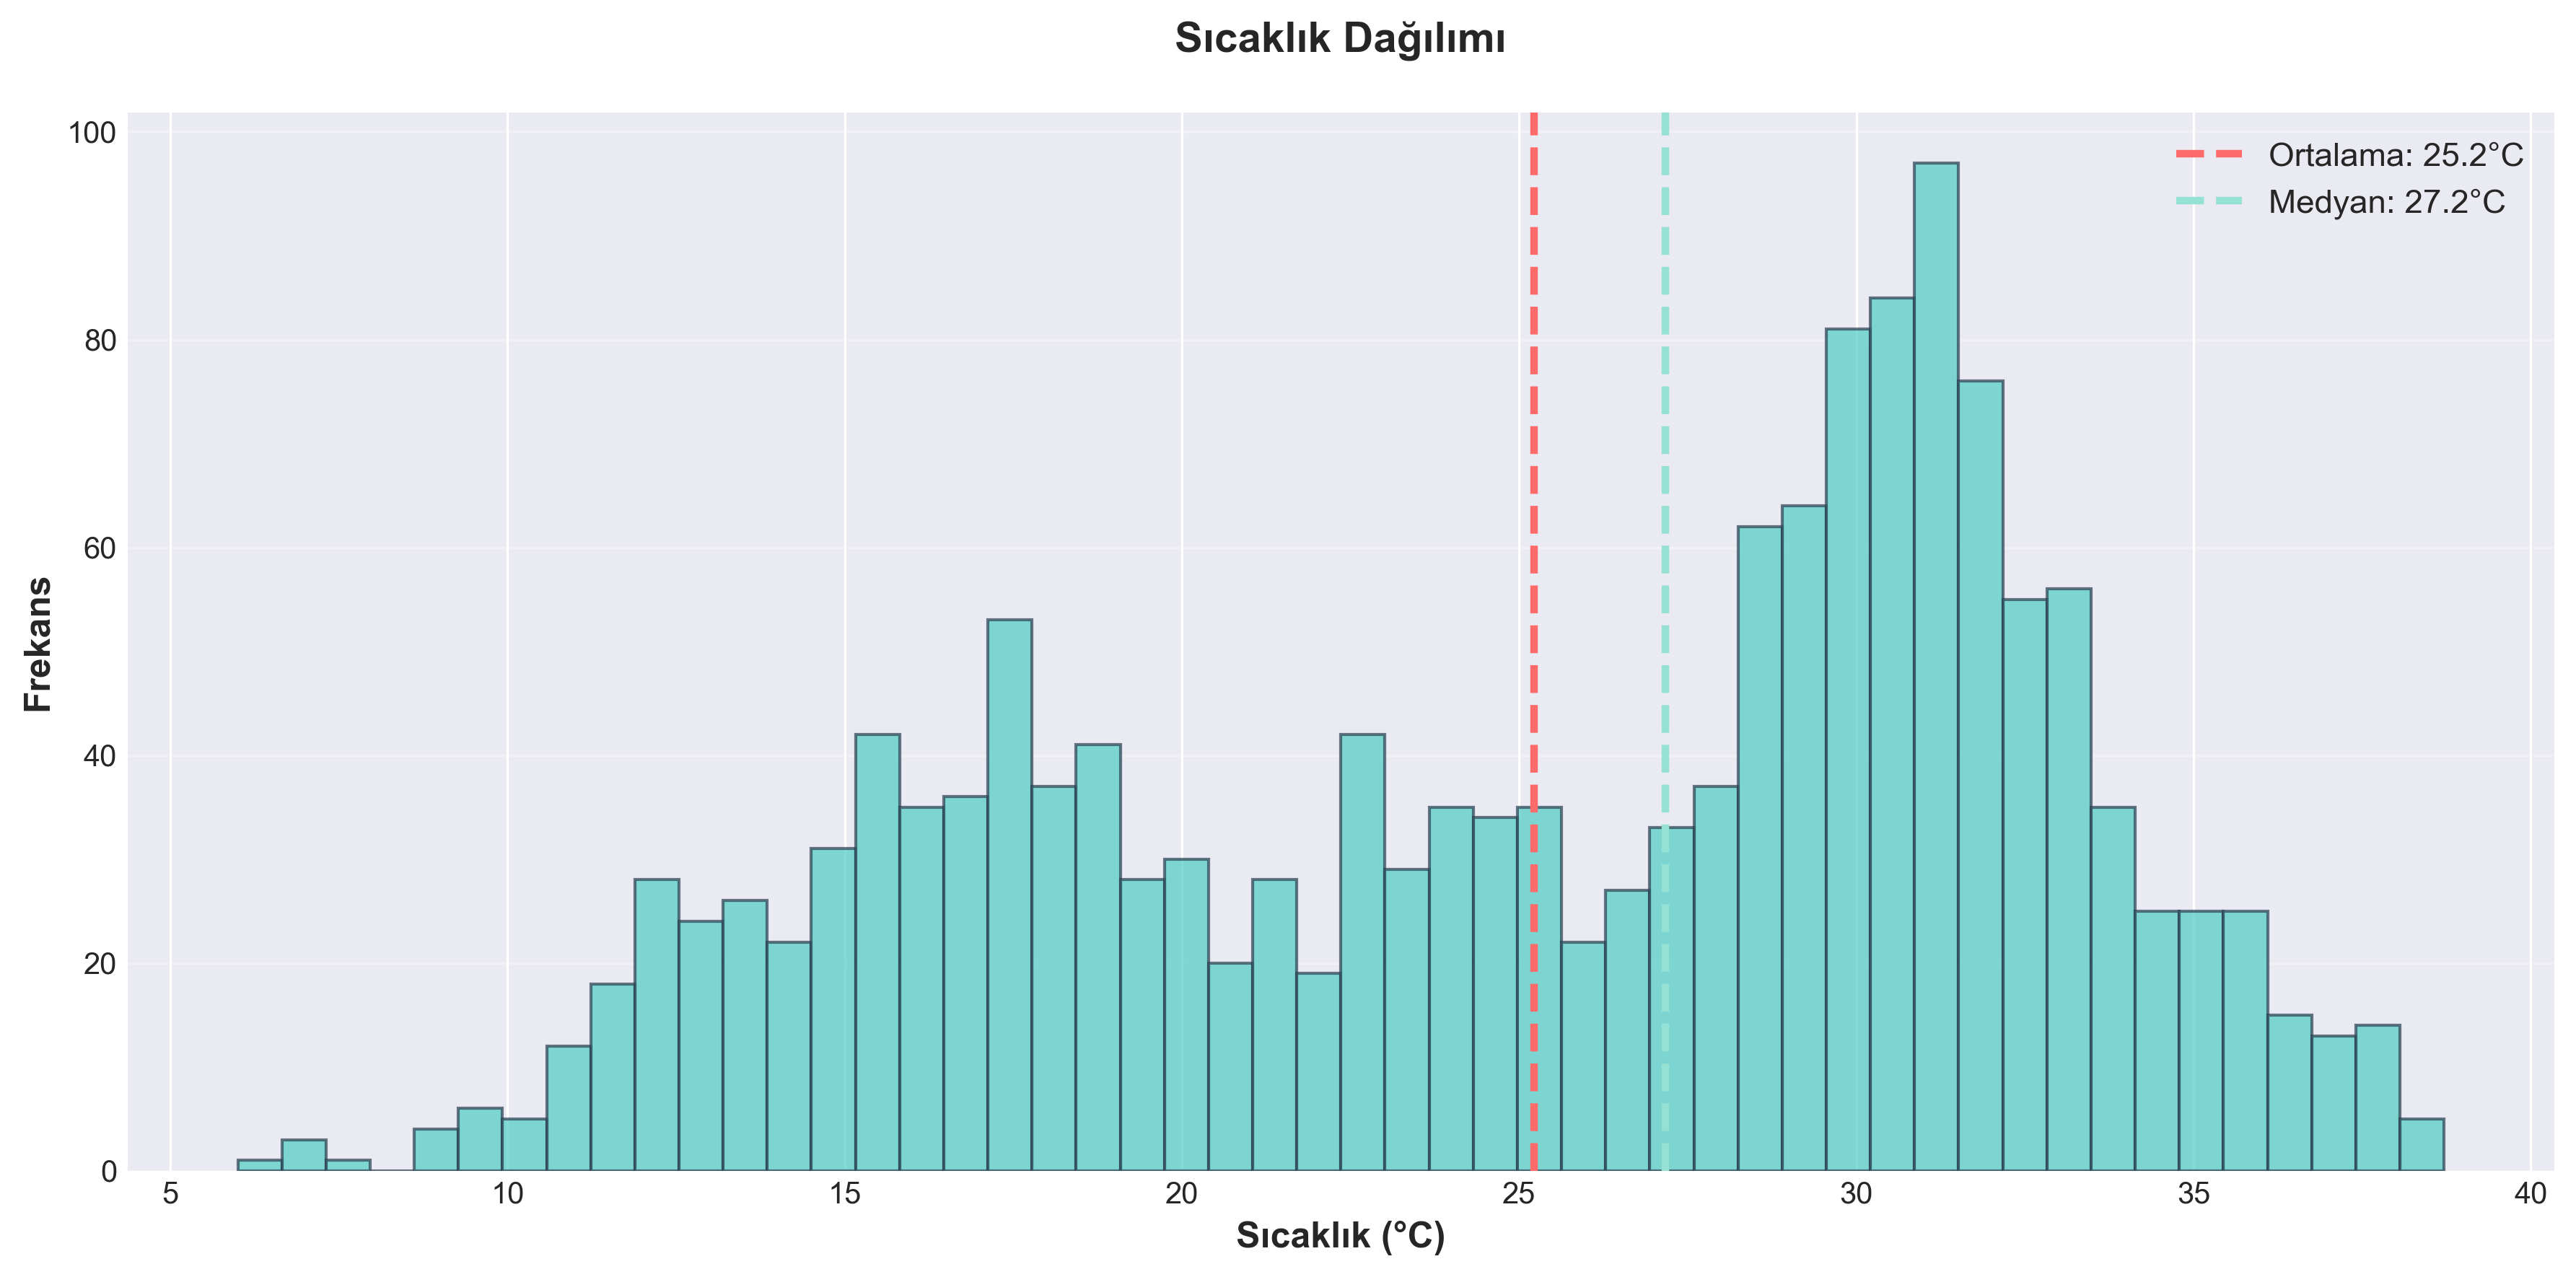

In [29]:
# SICAKLIK DAĞILIMI
plt.figure(figsize=(12, 6), dpi=300)
plt.hist(df['meantemp'], bins=50, color='#4ECDC4', edgecolor='#2C3E50', alpha=0.7)
plt.axvline(df['meantemp'].mean(), color='#FF6B6B', linestyle='--', linewidth=2.5, label=f'Ortalama: {df["meantemp"].mean():.1f}°C')
plt.axvline(df['meantemp'].median(), color='#95E1D3', linestyle='--', linewidth=2.5, label=f'Medyan: {df["meantemp"].median():.1f}°C')
plt.xlabel('Sıcaklık (°C)', fontsize=12, fontweight='bold')
plt.ylabel('Frekans', fontsize=12, fontweight='bold')
plt.title('Sıcaklık Dağılımı', fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

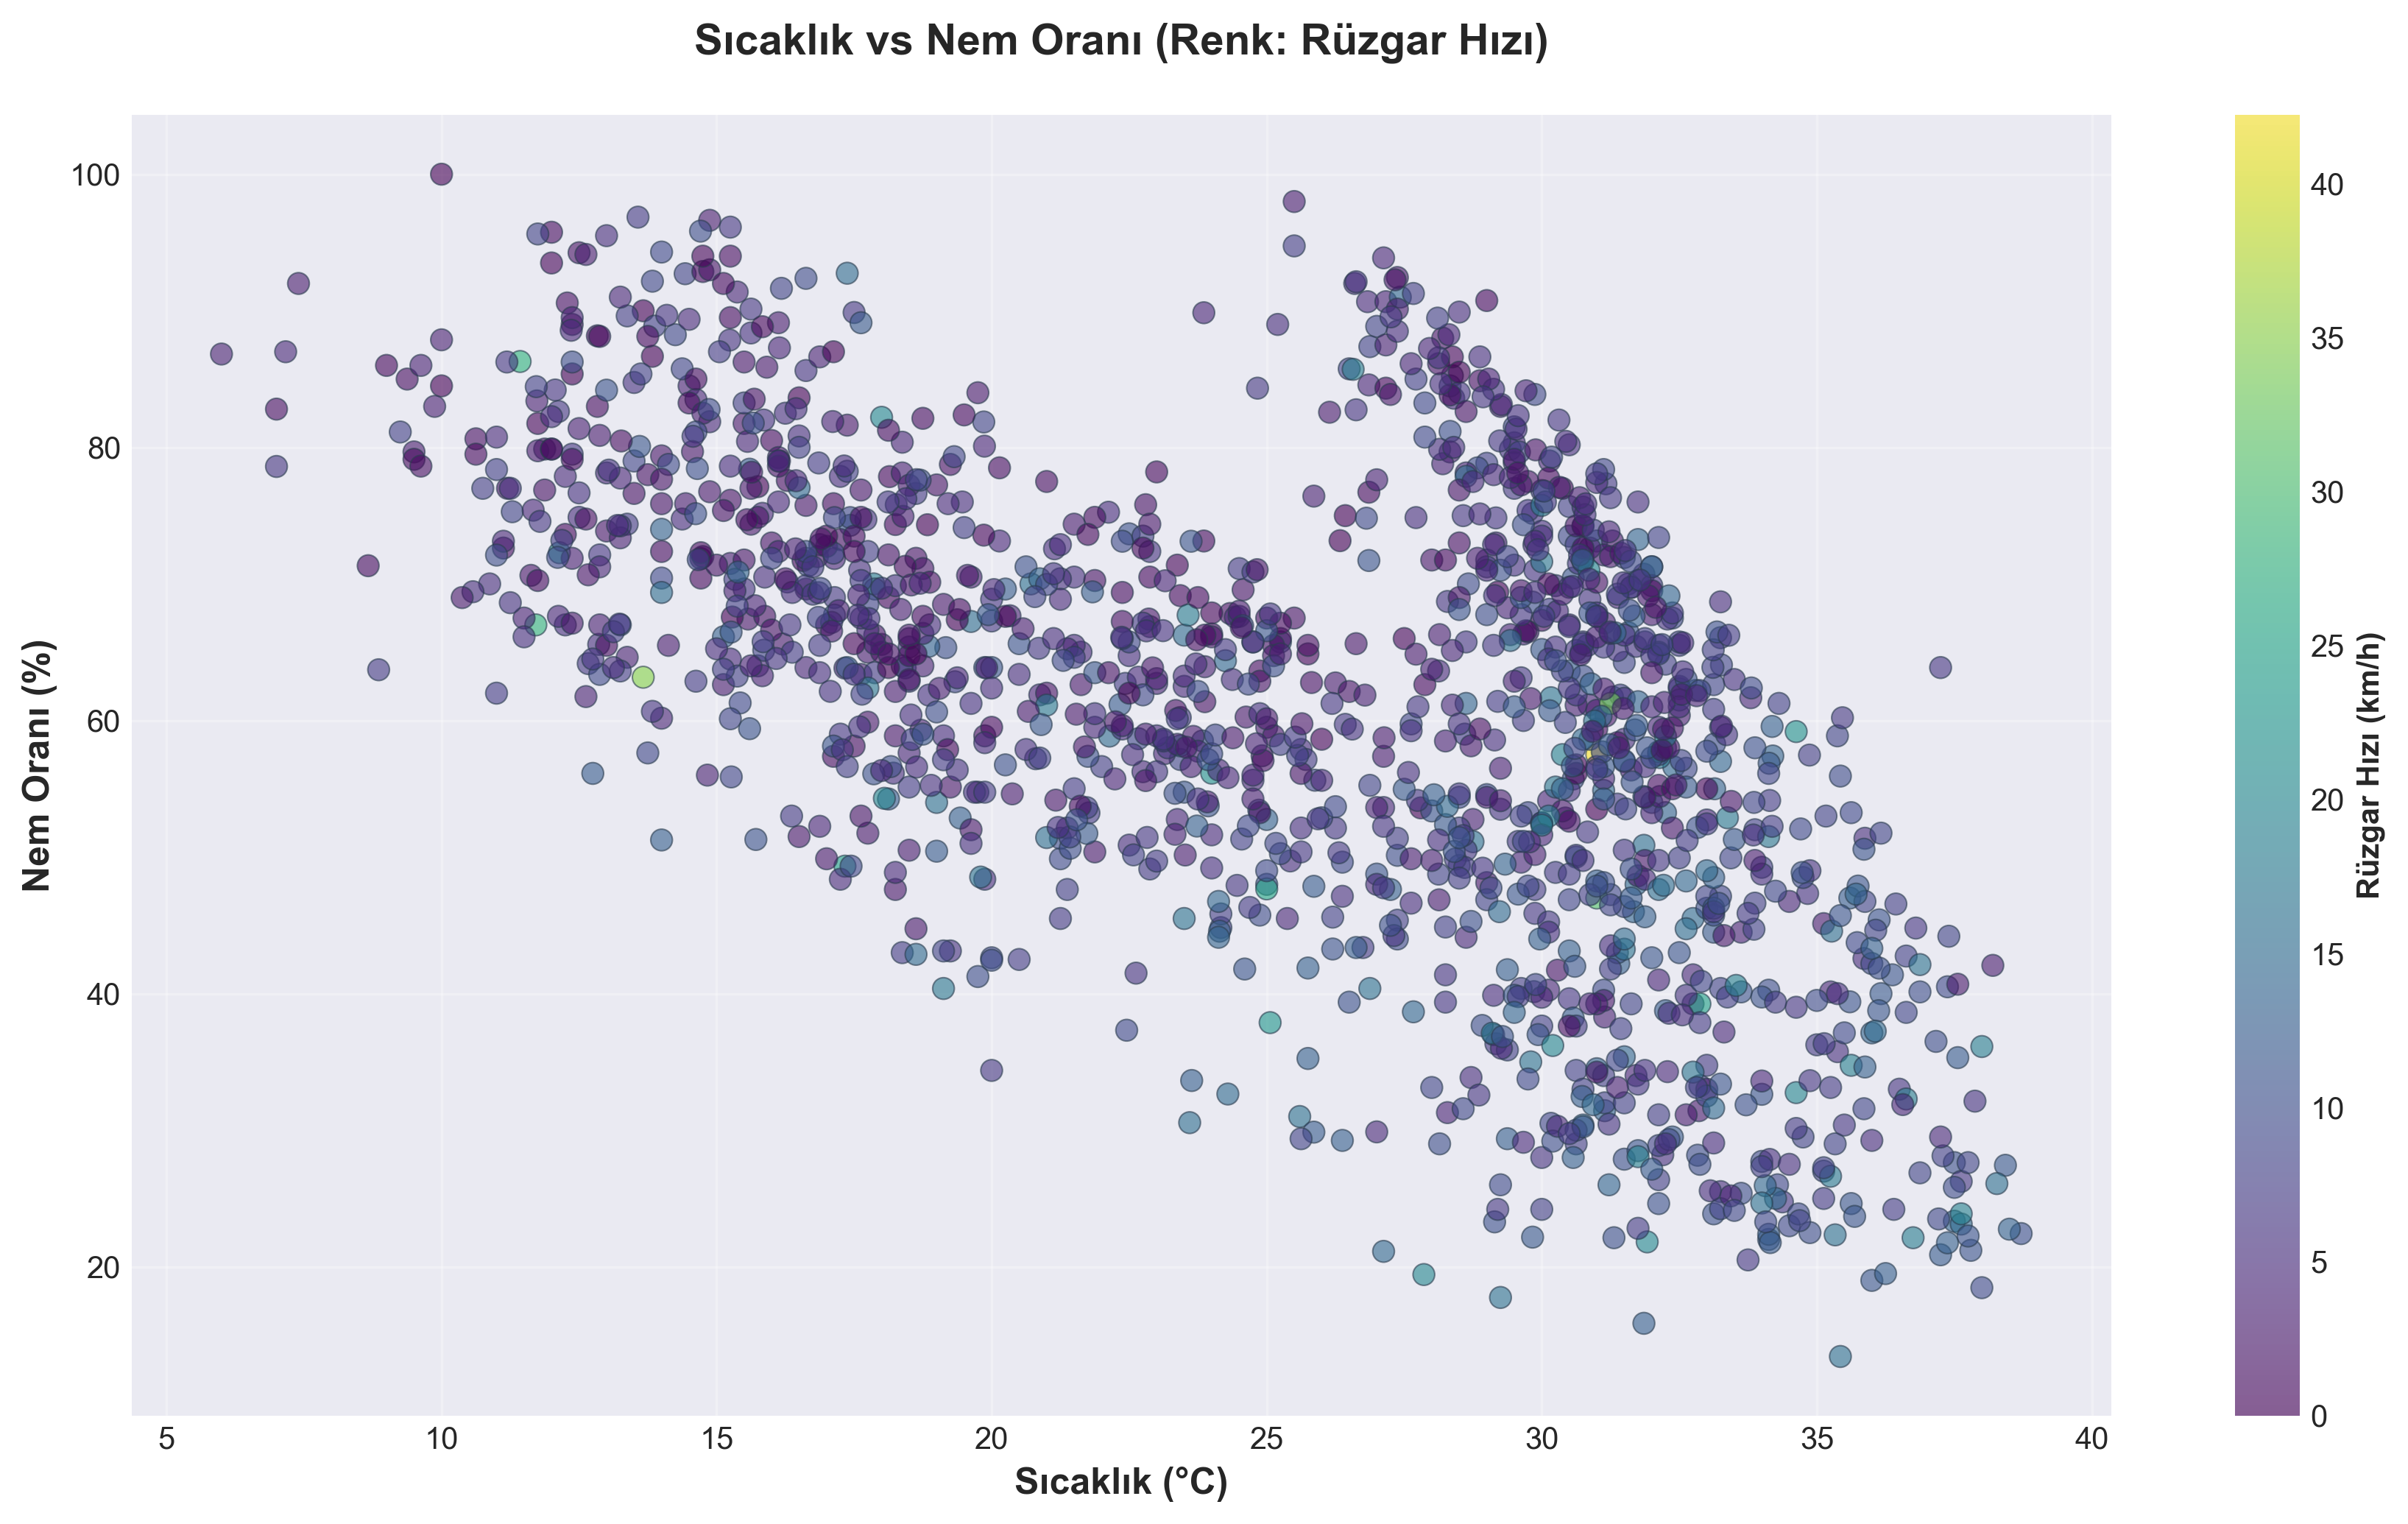

In [36]:
# NEM VE SICAKLIK SCATTER PLOT
plt.figure(figsize=(12, 7), dpi=300)

scatter = plt.scatter(df['meantemp'], df['humidity'], c=df['wind_speed'], 
                     cmap='viridis', s=50, alpha=0.6, edgecolors='#2C3E50', linewidth=0.5)

plt.xlabel('Sıcaklık (°C)', fontsize=12, fontweight='bold')
plt.ylabel('Nem Oranı (%)', fontsize=12, fontweight='bold')
plt.title('Sıcaklık vs Nem Oranı (Renk: Rüzgar Hızı)', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Rüzgar Hızı (km/h)', fontweight='bold')

plt.tight_layout()

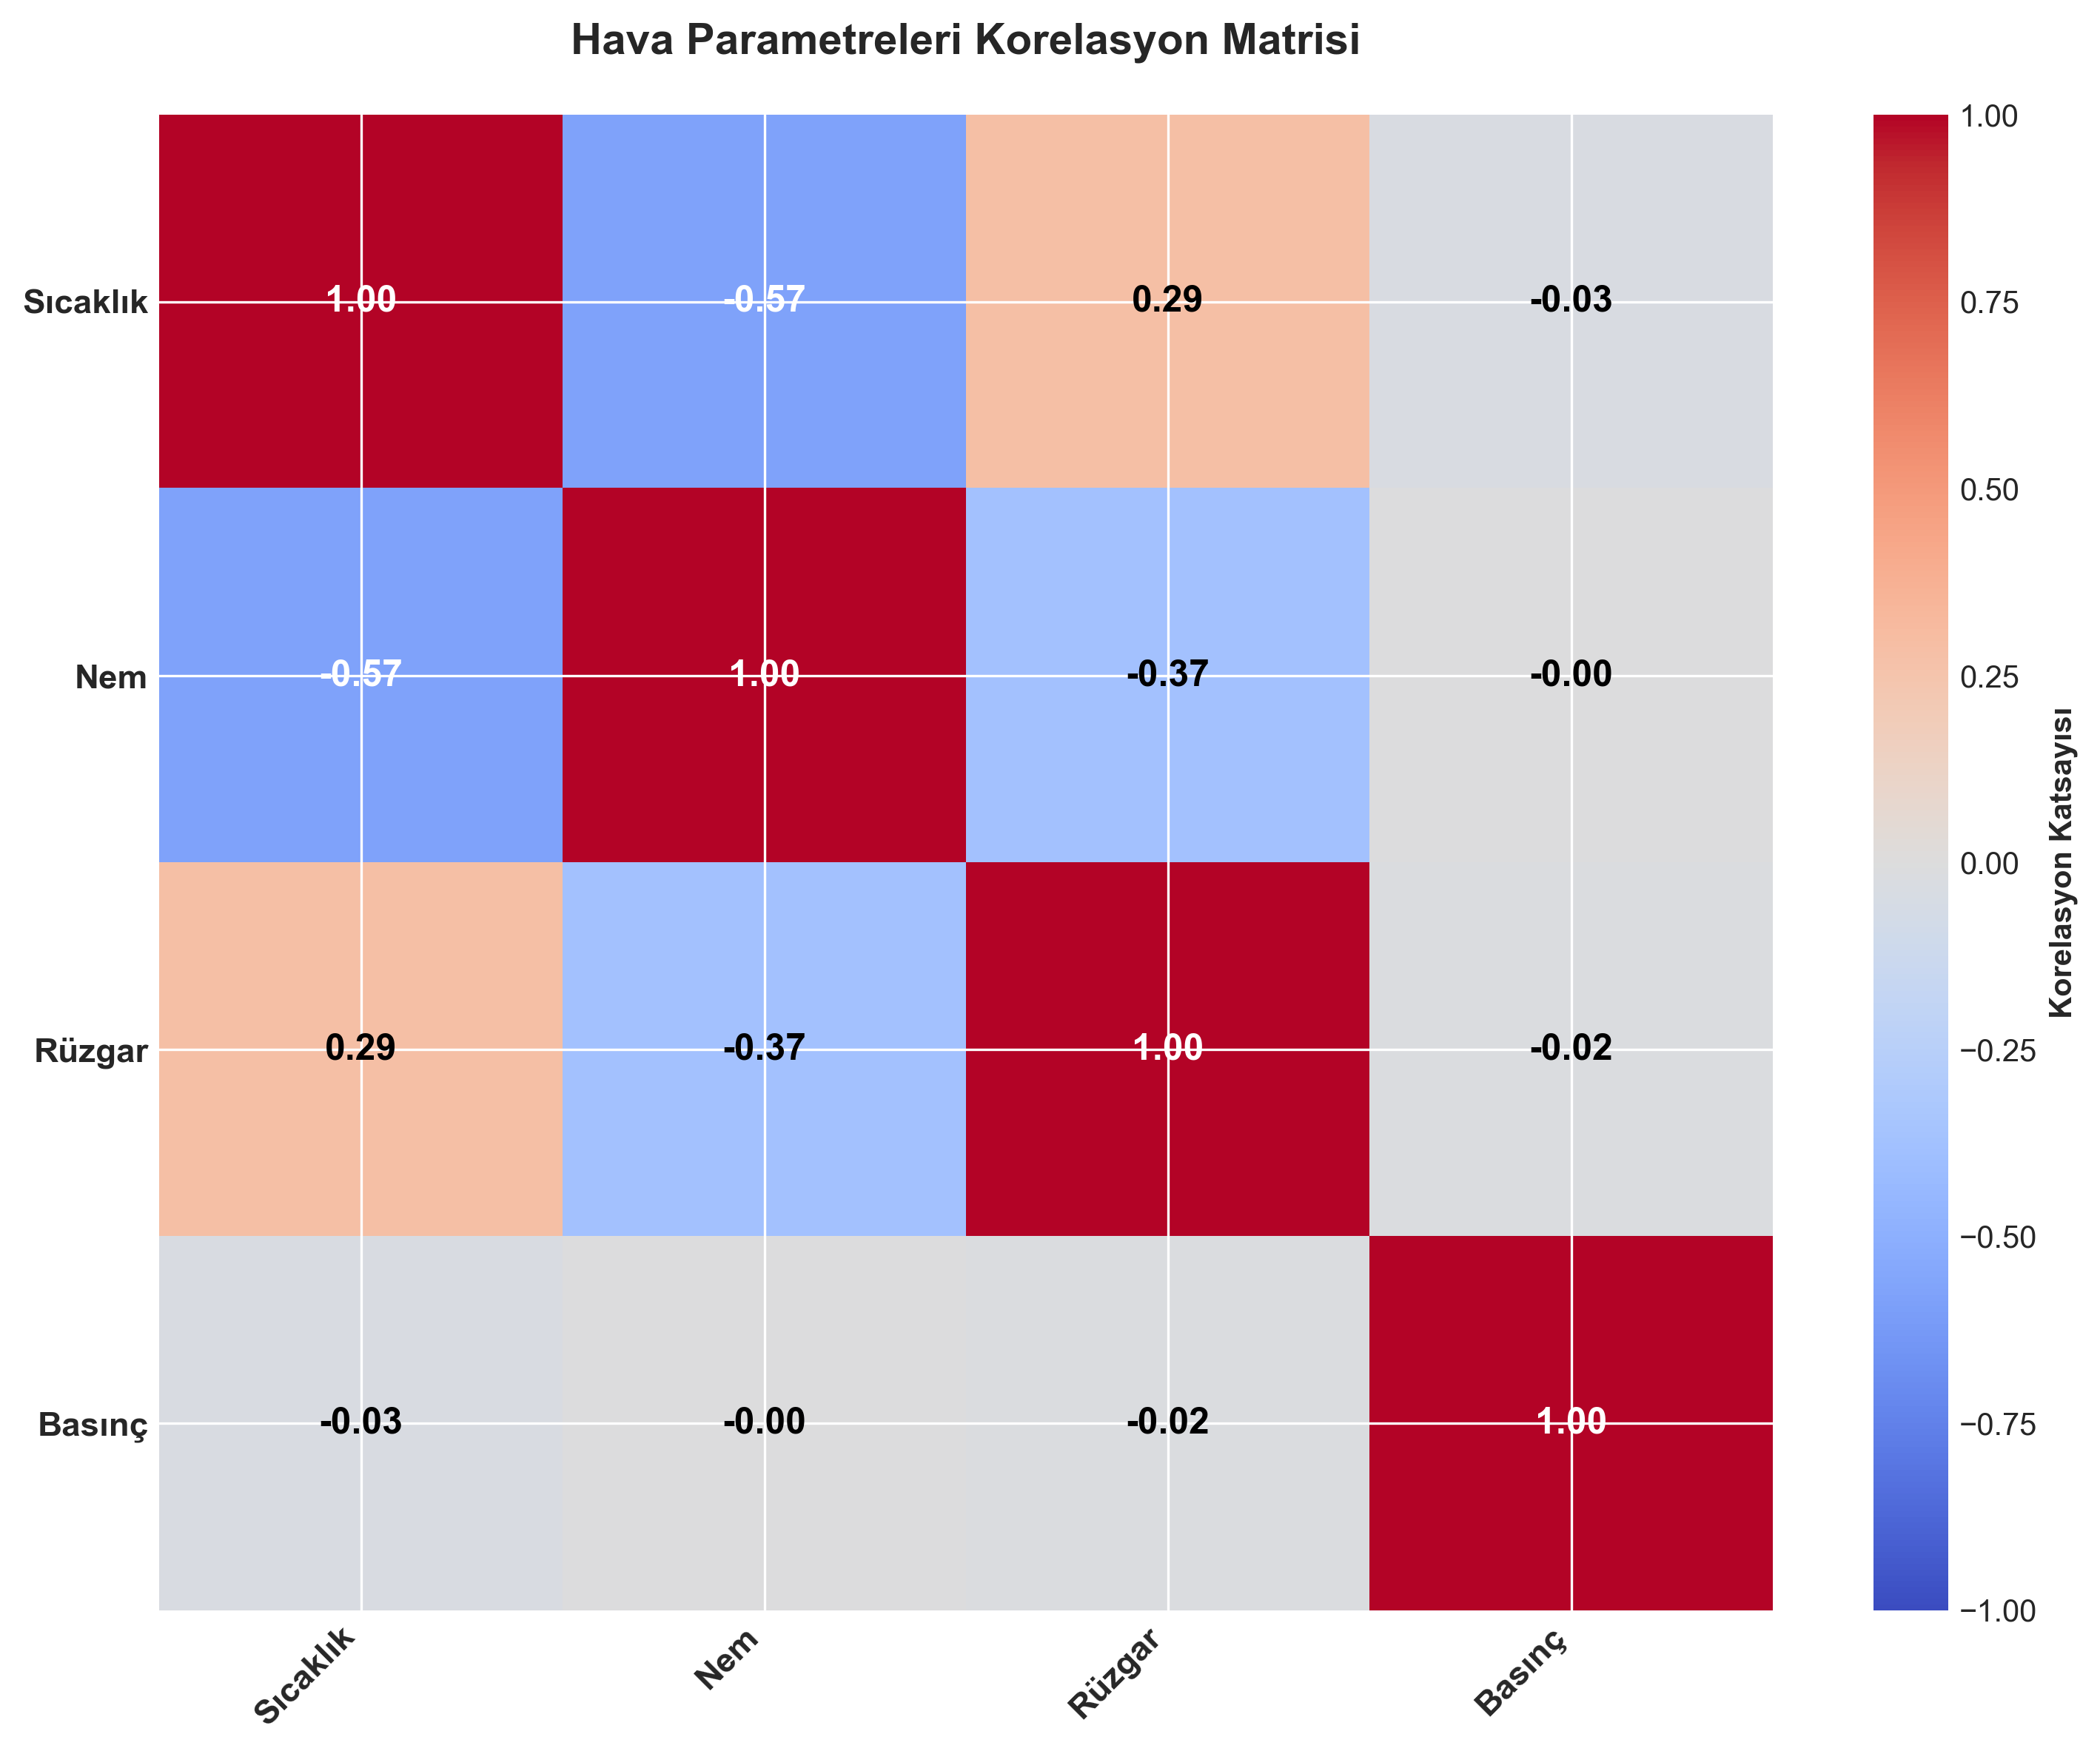

In [34]:
#KORELASYON HEATMAP
plt.figure(figsize=(10, 8), dpi=300)

corr_matrix = df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].corr()
im = plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

columns = ['Sıcaklık', 'Nem', 'Rüzgar', 'Basınç']
plt.xticks(np.arange(len(columns)), columns, fontsize=11, fontweight='bold', rotation=45, ha="right")
plt.yticks(np.arange(len(columns)), columns, fontsize=11, fontweight='bold')

for i in range(len(columns)):
    for j in range(len(columns)):
        value = corr_matrix.iloc[i, j]
        color = 'white' if abs(value) > 0.5 else 'black'
        plt.text(j, i, f'{value:.2f}', ha="center", va="center", 
                color=color, fontsize=12, fontweight='bold')

plt.title('Hava Parametreleri Korelasyon Matrisi', fontsize=14, fontweight='bold', pad=20)
cbar = plt.colorbar(im)
cbar.set_label('Korelasyon Katsayısı', fontweight='bold')
plt.tight_layout()

In [26]:
#Forecasting with Prophet

In [19]:
df_prophet = df[['date', 'meantemp']]
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet = df_prophet.sort_values('ds').reset_index(drop=True)

print("=" * 60)
print("HAVA DURUMU SICAKLIK TAHMİNİ - PROPHET")
print("=" * 60)
print(f"Toplam veri satırı: {len(df_prophet)}")
print(f"Tarih aralığı: {df_prophet['ds'].min()} - {df_prophet['ds'].max()}")
print()

HAVA DURUMU SICAKLIK TAHMİNİ - PROPHET
Toplam veri satırı: 1576
Tarih aralığı: 2013-01-01 00:00:00 - 2017-04-24 00:00:00



In [20]:
# ==================== 7 GÜNLÜK TAHMİN ====================
print("7 GÜNLÜK SICAKLIK TAHMİNİ")
print("-" * 60)

# Model oluşturup eğitelim
model_7d = Prophet(yearly_seasonality=True, daily_seasonality=False)
model_7d.fit(df_prophet)

# 7 günlük tahmin
future_7d = model_7d.make_future_dataframe(periods=7)
forecast_7d = model_7d.predict(future_7d)

# Tahmin sonuçlarını göster
forecast_7d_display = forecast_7d[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)
print("\n7 Gün İleri Sıcaklık Tahmini:")
print(forecast_7d_display.to_string(index=False))

7 GÜNLÜK SICAKLIK TAHMİNİ
------------------------------------------------------------


20:02:48 - cmdstanpy - INFO - Chain [1] start processing
20:02:49 - cmdstanpy - INFO - Chain [1] done processing



7 Gün İleri Sıcaklık Tahmini:
        ds      yhat  yhat_lower  yhat_upper
2017-04-25 32.864899   30.161693   35.407899
2017-04-26 33.138474   30.473927   35.821820
2017-04-27 33.232256   30.244552   35.752902
2017-04-28 33.303798   30.757617   35.926358
2017-04-29 33.319313   30.805667   35.901288
2017-04-30 33.381879   30.819462   35.933712
2017-05-01 33.674856   31.178717   36.252619


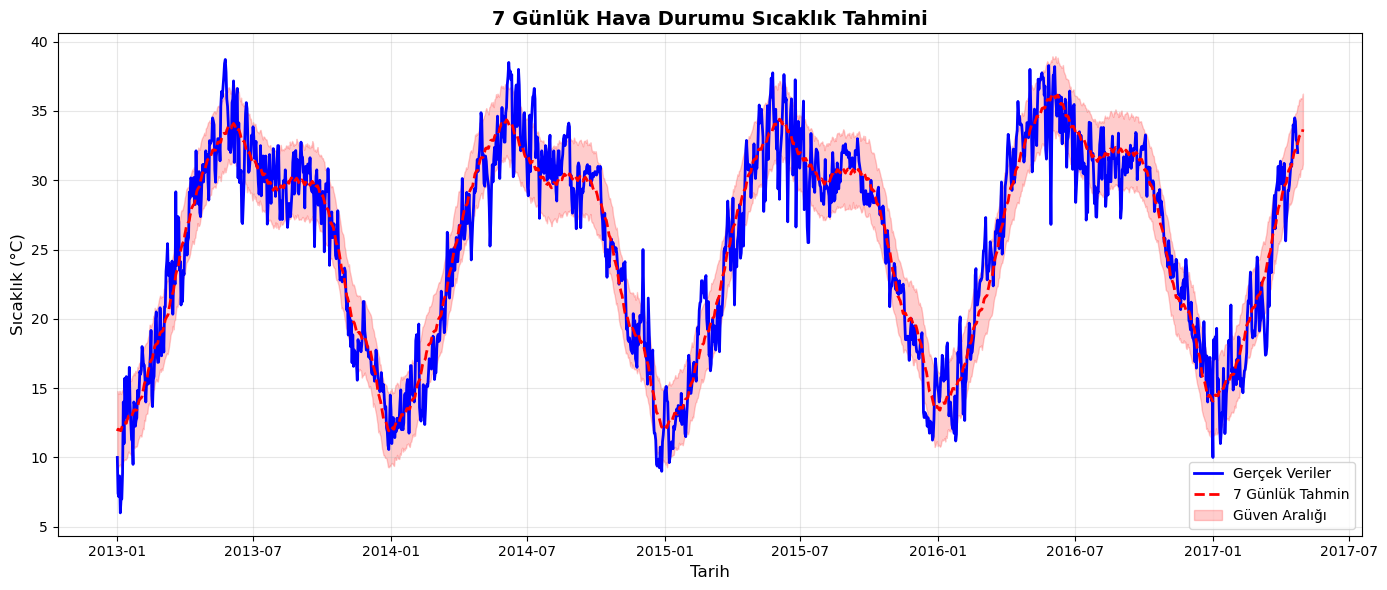

In [21]:
# Hava Tahmin Grafiği
plt.figure(figsize=(14, 6))
plt.plot(df_prophet['ds'], df_prophet['y'], 'b-', linewidth=2, label='Gerçek Veriler')
plt.plot(forecast_7d['ds'], forecast_7d['yhat'], 'r--', linewidth=2, label='7 Günlük Tahmin')
plt.fill_between(forecast_7d['ds'], forecast_7d['yhat_lower'], forecast_7d['yhat_upper'],
                 color='red', alpha=0.2, label='Güven Aralığı')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Sıcaklık (°C)', fontsize=12)
plt.title('7 Günlük Hava Durumu Sıcaklık Tahmini', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# ==================== 30 GÜNLÜK TAHMİN ====================
print("\n" + "=" * 60)
print("30 GÜNLÜK SICAKLIK TAHMİNİ")
print("-" * 60)

# Model oluştur ve eğit
model_30d = Prophet(yearly_seasonality=True, daily_seasonality=False)
model_30d.fit(df_prophet)

# 30 günlük tahmin
future_30d = model_30d.make_future_dataframe(periods=30)
forecast_30d = model_30d.predict(future_30d)

20:04:41 - cmdstanpy - INFO - Chain [1] start processing



30 GÜNLÜK SICAKLIK TAHMİNİ
------------------------------------------------------------


20:04:41 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
# Tahmin sonuçlarını göster
forecast_30d_display = forecast_30d[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)
print("\n30 Gün İleri Sıcaklık Tahmini (İlk 10 gün):")
print(forecast_30d_display.head(10).to_string(index=False))
print("\n...")
print("\n30 Gün İleri Sıcaklık Tahmini (Son 10 gün):")
print(forecast_30d_display.tail(10).to_string(index=False))


30 Gün İleri Sıcaklık Tahmini (İlk 10 gün):
        ds      yhat  yhat_lower  yhat_upper
2017-04-25 32.864899   30.184961   35.568333
2017-04-26 33.138474   30.615824   35.669782
2017-04-27 33.232256   30.658061   35.829128
2017-04-28 33.303798   30.710602   36.015665
2017-04-29 33.319313   30.604345   35.926830
2017-04-30 33.381879   30.691704   35.936845
2017-05-01 33.674856   30.930557   36.249843
2017-05-02 33.837381   31.265832   36.434315
2017-05-03 34.066395   31.396104   36.820848
2017-05-04 34.114946   31.434606   36.939296

...

30 Gün İleri Sıcaklık Tahmini (Son 10 gün):
        ds      yhat  yhat_lower  yhat_upper
2017-05-15 34.953634   32.305627   37.701329
2017-05-16 35.079540   32.444138   37.540990
2017-05-17 35.280256   32.643839   38.069800
2017-05-18 35.308610   32.585739   37.877081
2017-05-19 35.322537   32.775847   37.942318
2017-05-20 35.288347   32.703356   37.987479
2017-05-21 35.308915   32.666788   38.026386
2017-05-22 35.567101   32.961666   38.076712
2017-

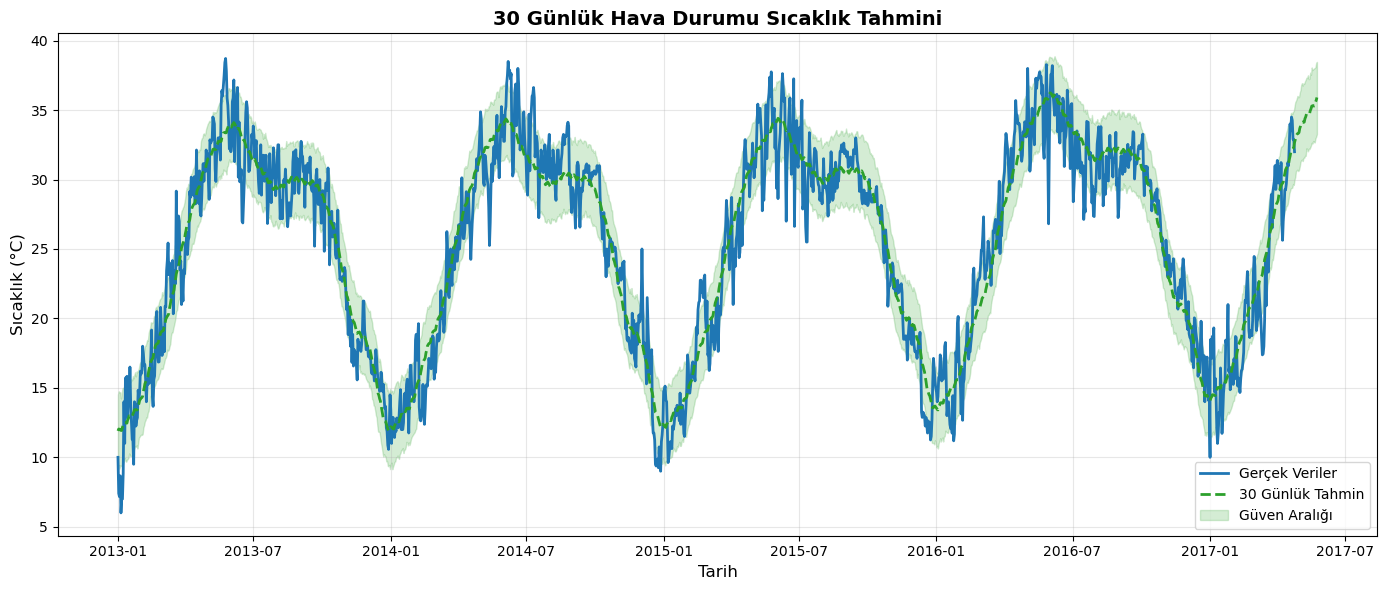

In [24]:
# 30 Günlük Hava Tahmini
plt.figure(figsize=(14, 6))
plt.plot(df_prophet['ds'], df_prophet['y'], color='#1f77b4', linewidth=2, label='Gerçek Veriler')
plt.plot(forecast_30d['ds'], forecast_30d['yhat'], color='#2ca02c', linestyle='--', linewidth=2, label='30 Günlük Tahmin')
plt.fill_between(forecast_30d['ds'],
                 forecast_30d['yhat_lower'],
                 forecast_30d['yhat_upper'],
                 color='#2ca02c', alpha=0.2, label='Güven Aralığı')

plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Sıcaklık (°C)', fontsize=12)
plt.title('30 Günlük Hava Durumu Sıcaklık Tahmini', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

20:25:50 - cmdstanpy - INFO - Chain [1] start processing
20:25:50 - cmdstanpy - INFO - Chain [1] done processing


MAE: 1.8285°C | R²: 0.0369


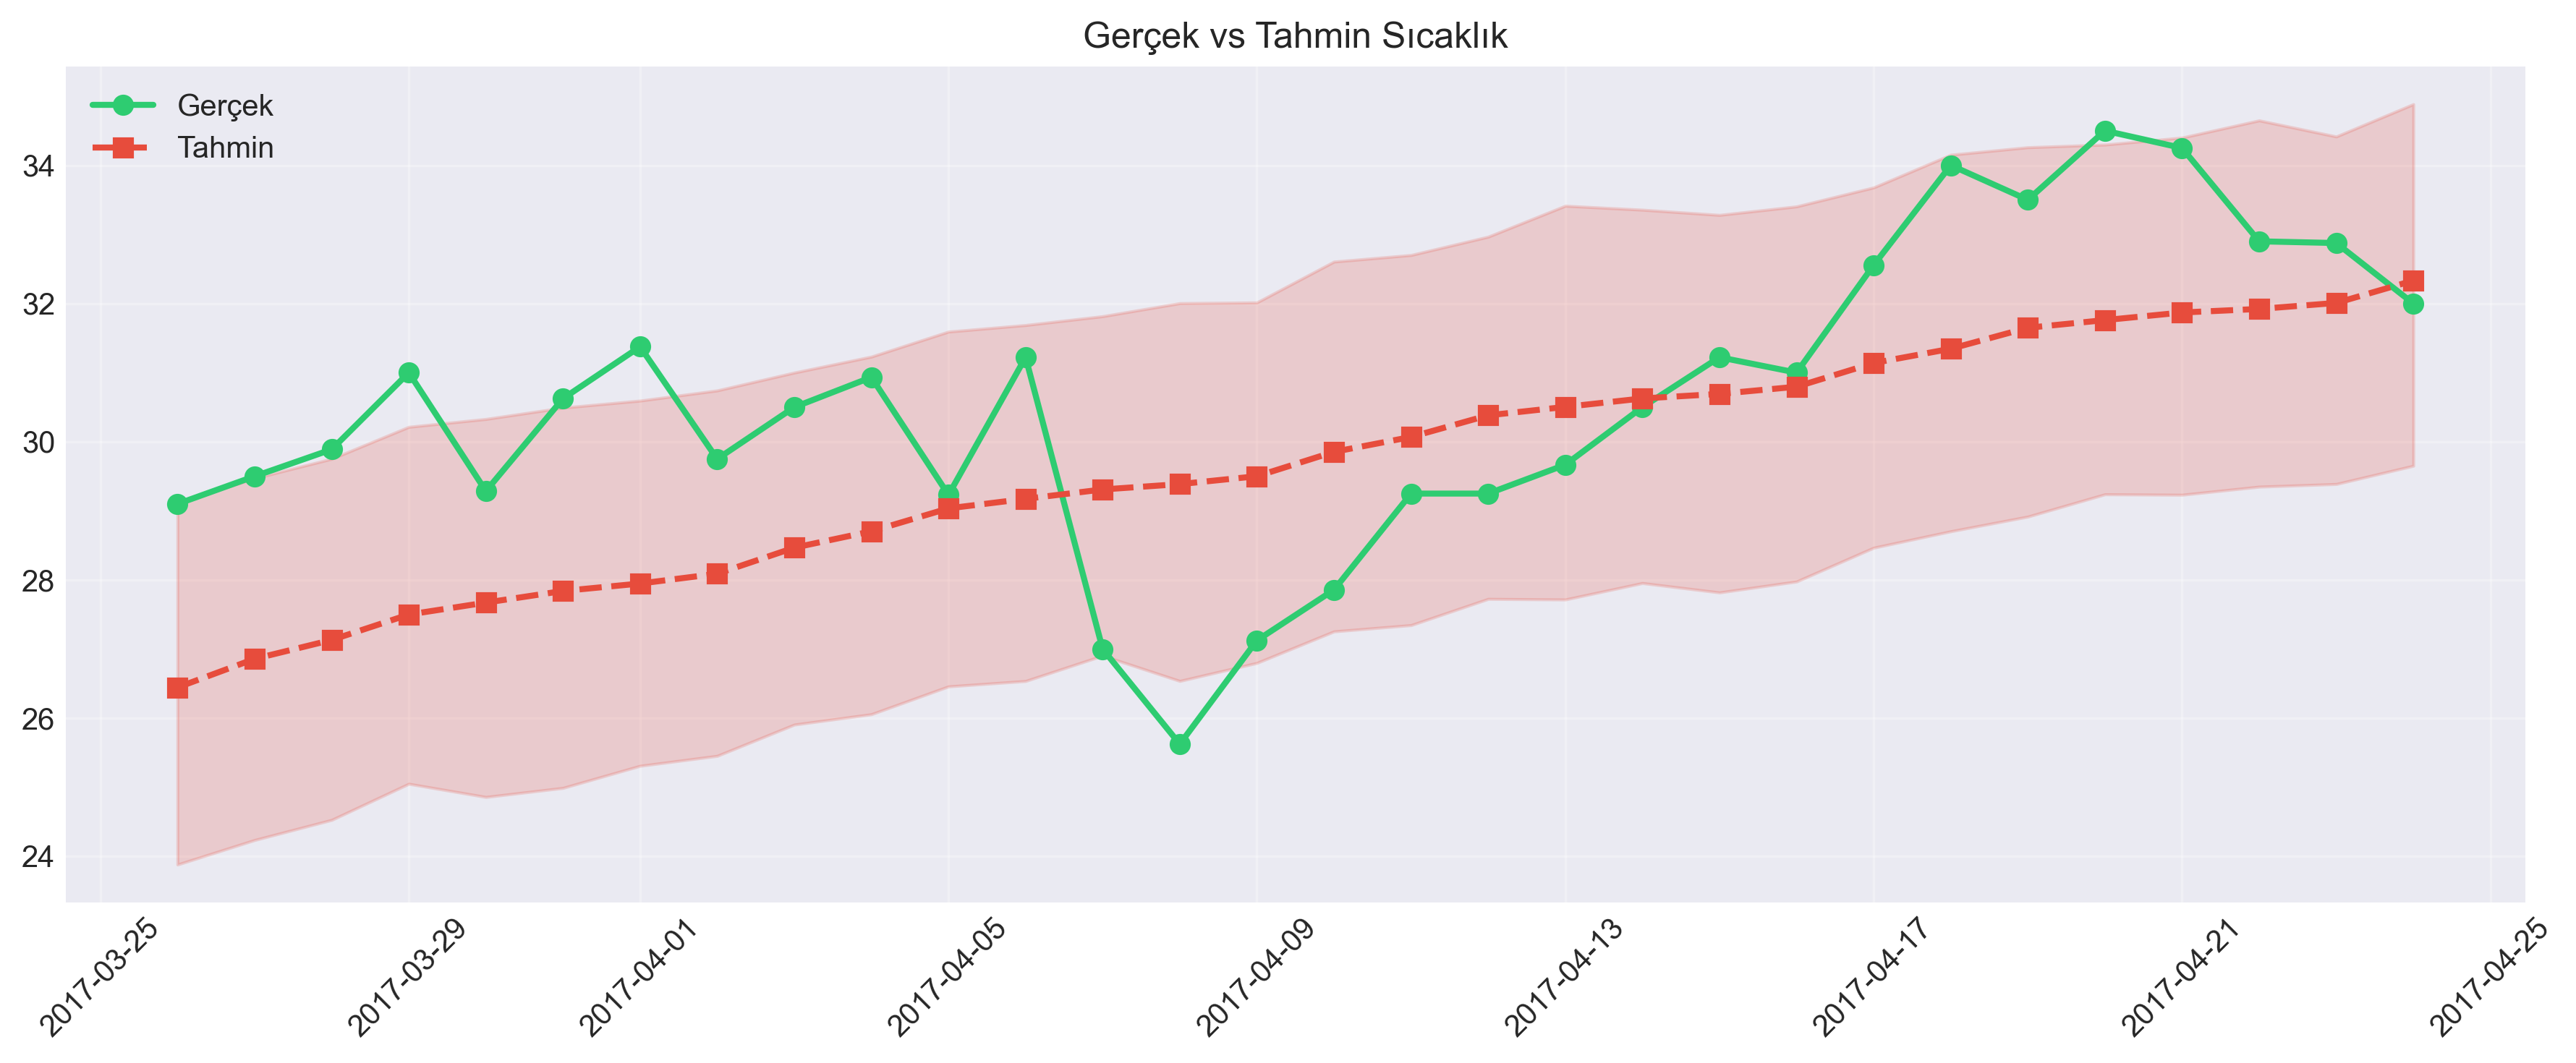

In [46]:
# Model eğit ve tahmin yap
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(train)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future).tail(30)

# Gerçek vs Tahmin
actual = test['y'].values
predicted_30d= forecast['yhat'].values

# Metrikler
mae = mean_absolute_error(actual, predicted_30d)
r2 = r2_score(actual, predicted_30d)
print(f"MAE: {mae:.4f}°C | R²: {r2:.4f}")

# Grafikler
plt.figure(figsize=(12, 5), dpi=300)
plt.plot(test['ds'], actual, 'o-', label='Gerçek', color='#2ECC71', linewidth=2)
plt.plot(forecast['ds'], predicted_30d, 's--', label='Tahmin', color='#E74C3C', linewidth=2)
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                 alpha=0.2, color='#E74C3C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Gerçek vs Tahmin Sıcaklık')
plt.xticks(rotation=45)
plt.tight_layout()

In [53]:
import pandas as pd
from prophet import Prophet
import pickle
import joblib

# Pickle ile kaydet
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✓ Model kaydedildi: model.pkl")

# Joblib ile kaydet
joblib.dump(model, 'model.joblib')
print("✓ Model kaydedildi: model.joblib")

# Kayıtlı modelleri yükle ve test et
print("\n--- Test: Modelleri yükleme ---")

# Pickle'dan yükle
model_pkl = pickle.load(open('model.pkl', 'rb'))
forecast_pkl = model_pkl.make_future_dataframe(periods=7)
pred_pkl = model_pkl.predict(forecast_pkl)
print(f"✓ Pickle modeli yüklendi (İlk tahmin: {pred_pkl['yhat'].iloc[-1]:.2f}°C)")

# Joblib'den yükle
model_joblib = joblib.load('model.joblib')
forecast_joblib = model_joblib.make_future_dataframe(periods=7)
pred_joblib = model_joblib.predict(forecast_joblib)
print(f"✓ Joblib modeli yüklendi (İlk tahmin: {pred_joblib['yhat'].iloc[-1]:.2f}°C)")

✓ Model kaydedildi: model.pkl
✓ Model kaydedildi: model.joblib

--- Test: Modelleri yükleme ---
✓ Pickle modeli yüklendi (İlk tahmin: 27.95°C)
✓ Joblib modeli yüklendi (İlk tahmin: 27.95°C)


🇹🇷 Türkçe

Bu çalışmada, Prophet kütüphanesi kullanılarak hava durumu verileri üzerinde zaman serisi analizi gerçekleştirilmiş; 7 günlük (kısa vadeli) ve 30 günlük (orta vadeli) tahminler üretilmiş ve elde edilen sonuçlar karşılaştırmalı olarak değerlendirilmiştir.

🇬🇧 English

In this study, time series analysis was performed on weather data using the Prophet library; 7-day (short-term) and 30-day (medium-term) forecasts were generated, and the results were comparatively evaluated.